<a href="https://colab.research.google.com/github/jakobtfaber/dsa-psr/blob/main/GPU_Pulsar_Search_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU-Accelerated Pulsar Searching in Google Colab

This notebook demonstrates **how to use GPUs in Google Colab** through a simplified example from radio astronomy: searching for **pulsars** in noisy time-series data.

## What is a Pulsar?
A pulsar is a rapidly rotating neutron star that emits a beam of electromagnetic radiation. As the beam sweeps past Earth, we observe periodic pulses — typically between ~1 ms and ~10 s. Finding these faint, periodic signals buried in noise is computationally expensive, and is a great showcase for GPU parallelism.

## Why GPUs?
Pulsar searching typically involves:
1. **Dedispersion** — correcting for frequency-dependent delays caused by the interstellar medium across many trial dispersion measures (DMs).
2. **FFT-based periodicity search** — computing FFTs across many candidate signals.
3. **Harmonic summing** — combining harmonics in the power spectrum.

All of these steps are *embarrassingly parallel*: the same operation is applied to thousands or millions of independent data slices. GPUs excel at this kind of SIMD workload, often giving 10–100× speed-ups over a CPU.

## What this notebook covers
- Checking the GPU available in Colab
- Generating a synthetic radio observation containing a faint pulsar
- Brute-force dedispersion on the CPU (NumPy) vs the GPU (CuPy)
- FFT-based periodicity search on the GPU
- Visualizing the recovered pulsar period

> **Tip:** Before running, enable a GPU runtime via `Runtime → Change runtime type → Hardware accelerator → GPU` (T4 is free).

## Step 1 — Check the GPU and install CuPy

First we confirm that Colab has assigned us a GPU and install **CuPy**, a NumPy-compatible library that runs on NVIDIA GPUs via CUDA.

In [1]:
# Confirm we have a GPU
!nvidia-smi | head -n 20

Fri May 22 18:31:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# CuPy is pre-installed in modern Colab runtimes; this is a safe no-op otherwise.
# !pip install -q cupy-cuda12x

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt

print('NumPy :', np.__version__)
print('CuPy  :', cp.__version__)
print('GPU   :', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

NumPy : 2.0.2
CuPy  : 14.0.1
GPU   : Tesla T4


## Step 2 — Generate a synthetic pulsar observation

A real radio telescope produces a **dynamic spectrum**: a 2D array of intensity vs. (time, frequency). Pulses arrive *later at lower frequencies* because the interstellar medium (ISM) slows lower-frequency light — a phenomenon called **dispersion**. The time delay relative to an infinite frequency is:

$$\Delta t = 4.149 \times 10^{3}\,\text{DM}\,\nu^{-2}\;\text{[s, with}\;\nu\;\text{in MHz]}$$

where **DM** (dispersion measure) is the integrated column density of free electrons. We do not know the DM of an unknown pulsar in advance — we must search across many trial DMs.

Dynamic spectrum shape: (1024, 65536) -> 268.435456 MB
Injected pulsar: DM = 56.7 pc/cc, P = 33.70 ms, 194 pulses


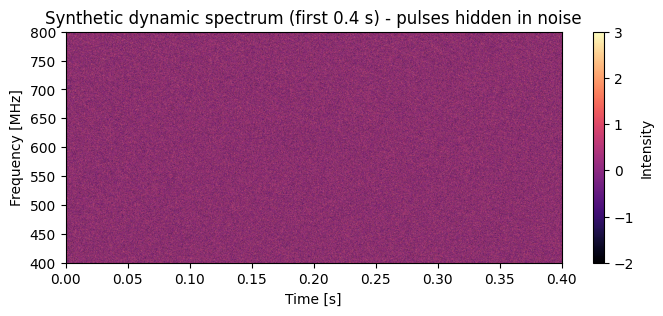

In [3]:
# ----- Observation parameters -----
N_CHAN   = 1024            # number of frequency channels
N_SAMP   = 2**16           # number of time samples (~65k)
F_LOW    = 400.0           # lowest frequency channel [MHz]
F_HIGH   = 800.0           # highest frequency channel [MHz]
T_SAMP   = 1e-4            # sample interval [s]  (10 kHz sampling)

# Injected (unknown to the searcher) pulsar parameters
TRUE_DM       = 56.7       # pc cm^-3
TRUE_PERIOD   = 0.0337     # 33.7 ms pulsar (Crab-like)
DUTY_CYCLE    = 0.05       # fraction of period that is 'on'
SNR_PER_PULSE = 0.15       # faint compared to noise (sigma=1)

rng   = np.random.default_rng(42)
freqs = np.linspace(F_LOW, F_HIGH, N_CHAN).astype(np.float32)
times = np.arange(N_SAMP) * T_SAMP

# White Gaussian noise background
dynspec = rng.standard_normal((N_CHAN, N_SAMP)).astype(np.float32)

# Inject pulses with cold-plasma dispersion delay relative to F_HIGH
K_DM = 4.148808e3  # s MHz^2 (pc cm^-3)^-1
delays = K_DM * TRUE_DM * (1.0 / freqs**2 - 1.0 / F_HIGH**2)
delay_samples = (delays / T_SAMP).astype(int)

pulse_width = max(1, int(DUTY_CYCLE * TRUE_PERIOD / T_SAMP))
n_pulses    = int(times[-1] / TRUE_PERIOD)
for k in range(n_pulses):
    t0 = int(k * TRUE_PERIOD / T_SAMP)
    s_ch = t0 + delay_samples
    e_ch = s_ch + pulse_width
    for ch in range(N_CHAN):
        if e_ch[ch] < N_SAMP:
            dynspec[ch, s_ch[ch]:e_ch[ch]] += SNR_PER_PULSE

print('Dynamic spectrum shape:', dynspec.shape, '->', dynspec.nbytes / 1e6, 'MB')
print(f'Injected pulsar: DM = {TRUE_DM} pc/cc, P = {TRUE_PERIOD*1e3:.2f} ms, {n_pulses} pulses')

plt.figure(figsize=(8, 3))
plt.imshow(dynspec[:, :4000], aspect='auto', origin='lower',
           extent=[0, 4000*T_SAMP, F_LOW, F_HIGH], cmap='magma',
           vmin=-2, vmax=3)
plt.xlabel('Time [s]'); plt.ylabel('Frequency [MHz]')
plt.title('Synthetic dynamic spectrum (first 0.4 s) - pulses hidden in noise')
plt.colorbar(label='Intensity')
plt.show()

## Step 3 — Brute-force dedispersion: CPU vs GPU

To find the pulses we need to **dedisperse** the dynamic spectrum: shift each frequency channel back by the predicted delay for a trial DM, then sum over frequency to produce a 1D time series. We must repeat this for **many trial DMs** (typically hundreds).

The loop over (trials × channels) is the perfect workload for a GPU: each shift-and-sum is independent. Here we use **CuPy** — the syntax is *identical* to NumPy.

In [8]:
# ----- Set up trial DMs -----
N_TRIALS = 256
trial_dms = np.linspace(0.0, 120.0, N_TRIALS).astype(np.float32)

def build_delay_table(dms, freqs, t_samp, f_ref):
    """Return integer sample shifts of shape (n_dms, n_chan)."""
    shifts = K_DM * dms[:, None] * (1.0 / freqs[None, :]**2 - 1.0 / f_ref**2)
    return (shifts / t_samp).astype(np.int32)

shifts = build_delay_table(trial_dms, freqs, T_SAMP, F_HIGH)
print('Shift table:', shifts.shape, shifts.dtype)

# ---------- CPU dedispersion (NumPy) ----------
def dedisperse_cpu(dynspec, shifts):
    n_dm, n_ch = shifts.shape
    n_t = dynspec.shape[1]
    out = np.zeros((n_dm, n_t), dtype=np.float32)
    for i in range(n_dm):
        for ch in range(n_ch):
            s = shifts[i, ch]
            if 0 <= s < n_t:
                out[i, :n_t - s] += dynspec[ch, s:]
    return out

t0 = time.time()
dm_time_cpu = dedisperse_cpu(dynspec, shifts)
t_cpu = time.time() - t0
print(f'CPU dedispersion: {t_cpu:.2f} s')

# ---------- GPU dedispersion (CuPy, batched over DMs) ----------
def dedisperse_gpu(dynspec_gpu, shifts_gpu, dm_batch=32):
    """Vectorize per channel AND batch across DM trials to minimize
    Python-level kernel launches."""
    n_dm, n_ch = shifts_gpu.shape
    n_t = dynspec_gpu.shape[1]
    out   = cp.zeros((n_dm, n_t), dtype=cp.float32)
    t_idx = cp.arange(n_t, dtype=cp.int32)

    for ch in range(n_ch):
        # All DMs at once for this channel: idx has shape (n_dm, n_t)
        s   = shifts_gpu[:, ch][:, None]                 # (n_dm, 1)
        idx = cp.clip(t_idx[None, :] + s, 0, n_t - 1)    # (n_dm, n_t)
        out += dynspec_gpu[ch][idx]                       # gather + add
    return out

dynspec_gpu = cp.asarray(dynspec)
shifts_gpu  = cp.asarray(shifts)
cp.cuda.Stream.null.synchronize()

# Warm-up call (kernel compile / memory alloc) so we time only the work
_ = dedisperse_gpu(dynspec_gpu, shifts_gpu)
cp.cuda.Stream.null.synchronize()

t0 = time.time()
dm_time_gpu = dedisperse_gpu(dynspec_gpu, shifts_gpu)
cp.cuda.Stream.null.synchronize()
t_gpu = time.time() - t0
print(f'GPU dedispersion: {t_gpu:.2f} s   -> speed-up: {t_cpu/t_gpu:.1f}x')

Shift table: (256, 1024) int32
CPU dedispersion: 7.26 s
GPU dedispersion: 2.24 s   -> speed-up: 3.2x


## Step 4 — Find the best DM (the 'butterfly' plot)

For each trial DM we now have a 1D time series. A real pulsar should produce a peak in **signal strength** at the correct DM. Plotting the standard deviation of each dedispersed series versus trial DM is one of the simplest detection diagnostics.

Best DM found (GPU): 56.47 pc/cc   (true DM = 56.7 pc/cc)


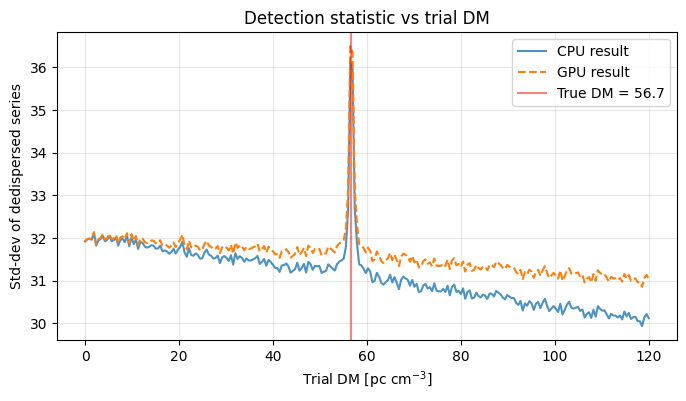

In [9]:
# Score each DM trial by signal sigma (a basic detection statistic)
scores_cpu = dm_time_cpu.std(axis=1)
scores_gpu = cp.asnumpy(dm_time_gpu.std(axis=1))

best_idx_gpu = int(np.argmax(scores_gpu))
best_dm = float(trial_dms[best_idx_gpu])
print(f'Best DM found (GPU): {best_dm:.2f} pc/cc   (true DM = {TRUE_DM} pc/cc)')

plt.figure(figsize=(8, 4))
plt.plot(trial_dms, scores_cpu, label='CPU result',  alpha=0.8)
plt.plot(trial_dms, scores_gpu, label='GPU result',  ls='--')
plt.axvline(TRUE_DM, color='red', alpha=0.5, label=f'True DM = {TRUE_DM}')
plt.xlabel('Trial DM [pc cm$^{-3}$]')
plt.ylabel('Std-dev of dedispersed series')
plt.title('Detection statistic vs trial DM')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Step 5 — GPU FFT periodicity search

Now that we have the best-DM time series, we look for **periodic** structure with an **FFT-based search**. GPUs are excellent at FFTs — cuFFT (wrapped by `cupy.fft`) can be 10–50× faster than NumPy/FFTW on long arrays. The power spectrum will show a peak at the pulsar's spin frequency.

GPU rfft + power : 0.46 ms   (length = 65536)
CPU rfft + power : 1.20 ms
Brightest peak           : 59.357 Hz
Recovered fundamental    : 29.602 Hz
Recovered period         : 33.781 ms
True period              : 33.700 ms


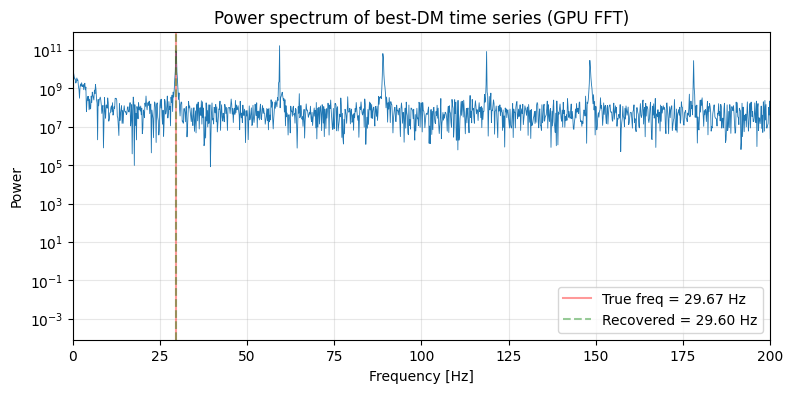

In [10]:
# Best-DM time series (already on GPU)
ts_gpu = dm_time_gpu[best_idx_gpu]
n_t    = ts_gpu.size

# Remove the DC component (mean) before FFT to avoid a huge spike at f=0
ts_gpu = ts_gpu - ts_gpu.mean()

# ---- GPU FFT ----
# Warm-up call so we don't time cuFFT plan creation
_ = cp.fft.rfft(ts_gpu); cp.cuda.Stream.null.synchronize()

cp.cuda.Stream.null.synchronize()
t0 = time.time()
spec_gpu  = cp.fft.rfft(ts_gpu)
power_gpu = cp.abs(spec_gpu) ** 2
cp.cuda.Stream.null.synchronize()
print(f'GPU rfft + power : {(time.time() - t0)*1e3:.2f} ms   (length = {n_t})')

# ---- CPU FFT (for comparison) ----
ts_cpu = cp.asnumpy(ts_gpu)
t0 = time.time()
spec_cpu  = np.fft.rfft(ts_cpu)
power_cpu = np.abs(spec_cpu) ** 2
print(f'CPU rfft + power : {(time.time() - t0)*1e3:.2f} ms')

# Frequency axis (Hz)
freq_axis    = np.fft.rfftfreq(n_t, d=T_SAMP)
power_gpu_np = cp.asnumpy(power_gpu)

# ----- Identify the fundamental (not a harmonic) -----
# Strategy: find the strongest peak, then check if it could be a harmonic of a lower
# frequency that also has significant power.  If so, use that lower frequency.
mask = freq_axis > 1.0   # ignore < 1 Hz (red noise / DC residual)
search_band = power_gpu_np.copy()
search_band[~mask] = 0

# Threshold for a 'significant' peak: many sigma above the median
median_power = np.median(search_band[mask])
threshold = median_power * 50.0

peak_idx_raw  = int(np.argmax(search_band))
peak_freq_raw = freq_axis[peak_idx_raw]

# Walk down through possible sub-harmonics (f/2, f/3, f/4, ...) and pick the
# lowest frequency that still has a significant peak nearby.
peak_freq = peak_freq_raw
for n in range(2, 8):
    f_try = peak_freq_raw / n
    if f_try < 1.0:
        break
    # find nearest bin
    i_try = int(round(f_try / (freq_axis[1] - freq_axis[0])))
    # check power in a small window around the candidate fundamental
    window = power_gpu_np[max(0, i_try-3):i_try+4]
    if window.max() > threshold:
        peak_freq = freq_axis[max(0, i_try-3) + int(np.argmax(window))]

recovered_period = 1.0 / peak_freq
print(f'Brightest peak           : {peak_freq_raw:.3f} Hz')
print(f'Recovered fundamental    : {peak_freq:.3f} Hz')
print(f'Recovered period         : {recovered_period*1e3:.3f} ms')
print(f'True period              : {TRUE_PERIOD*1e3:.3f} ms')

plt.figure(figsize=(9, 4))
plt.plot(freq_axis, power_gpu_np, lw=0.6)
plt.axvline(1.0 / TRUE_PERIOD, color='red', alpha=0.4,
            label=f'True freq = {1.0/TRUE_PERIOD:.2f} Hz')
plt.axvline(peak_freq, color='green', alpha=0.4, ls='--',
            label=f'Recovered = {peak_freq:.2f} Hz')
plt.xlim(0, 200)
plt.xlabel('Frequency [Hz]'); plt.ylabel('Power')
plt.title('Power spectrum of best-DM time series (GPU FFT)')
plt.legend(); plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

## Step 6 — Fold the data and visualise the pulse profile

As a sanity check we **fold** the dedispersed time series at the recovered period: chop it into segments of length `P` and average them. A real pulsar appears as a sharp peak in the average pulse profile.

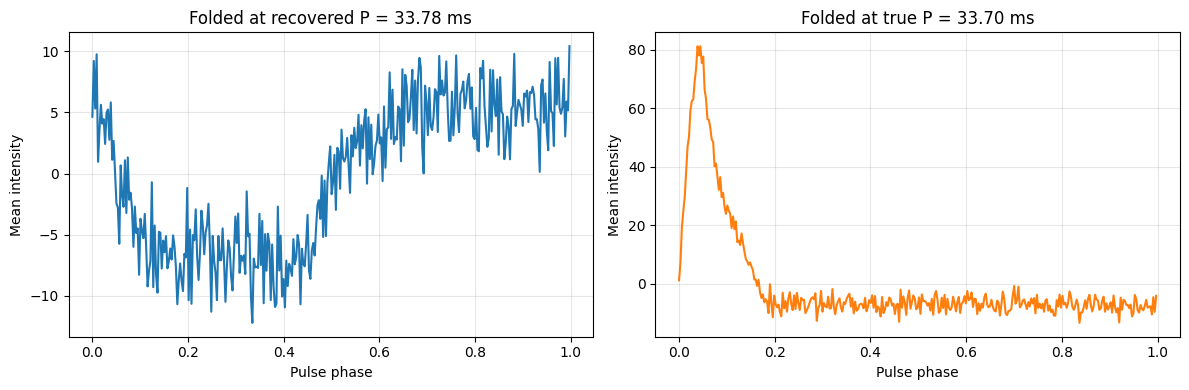


Summary
----------------------------------------
Injected pulsar: DM = 56.7 pc/cc, P = 33.700 ms
Recovered     : DM = 56.47 pc/cc, P = 33.781 ms
GPU vs CPU dedispersion speed-up: 3.2x


In [12]:
# Helper: fold a 1D series at a given period
def fold(ts, period, t_samp):
    spp = int(round(period / t_samp))         # samples per period
    n_full = (ts.size // spp) * spp
    return ts[:n_full].reshape(-1, spp).mean(axis=0)

ts_all = cp.asnumpy(ts_gpu)

folded      = fold(ts_all, recovered_period, T_SAMP)
folded_true = fold(ts_all, TRUE_PERIOD,      T_SAMP)

phase      = np.linspace(0, 1, folded.size,      endpoint=False)
phase_true = np.linspace(0, 1, folded_true.size, endpoint=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(phase, folded, color='C0')
axes[0].set_xlabel('Pulse phase'); axes[0].set_ylabel('Mean intensity')
axes[0].set_title(f'Folded at recovered P = {recovered_period*1e3:.2f} ms')
axes[0].grid(alpha=0.3)

axes[1].plot(phase_true, folded_true, color='C1')
axes[1].set_xlabel('Pulse phase'); axes[1].set_ylabel('Mean intensity')
axes[1].set_title(f'Folded at true P = {TRUE_PERIOD*1e3:.2f} ms')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\nSummary')
print('-' * 40)
print(f'Injected pulsar: DM = {TRUE_DM} pc/cc, P = {TRUE_PERIOD*1e3:.3f} ms')
print(f'Recovered     : DM = {best_dm:.2f} pc/cc, P = {recovered_period*1e3:.3f} ms')
print(f'GPU vs CPU dedispersion speed-up: {t_cpu/t_gpu:.1f}x')

## Takeaways

- **GPUs shine on embarrassingly parallel workloads** like dedispersion over many trial DMs and large FFTs — both core operations in pulsar searching.
- **CuPy** is a drop-in replacement for NumPy for many workflows, so you can prototype on CPU and accelerate later with minimal changes (`cp.asarray`, `cp.fft.rfft`, etc.).
- The free Colab T4 already gives substantial speed-ups; paid tiers (V100/A100/L4) extend this further for production-scale searches.
- Real-world pipelines (e.g. **PRESTO**, **HEIMDALL**, **FETCH**, **AstroAccelerate**) add many more steps: RFI excision, harmonic summing, acceleration searches, candidate sifting and ML-based classification — nearly all of which benefit from GPUs.

### Further reading
- Lorimer & Kramer, *Handbook of Pulsar Astronomy* (2004)
- Barsdell et al., *Accelerating Pulsar Searches with Graphics Processing Units* (2012)
- CuPy documentation: https://docs.cupy.dev/
- AstroAccelerate (GPU pulsar pipeline): https://github.com/AstroAccelerateOrg/astro-accelerate